In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


class Inception(nn.Module):
    # c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

In [2]:
b1=nn.Sequential(nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3),nn.BatchNorm2d(64),
                 nn.ReLU(),nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
b2=nn.Sequential(nn.Conv2d(64,64,kernel_size=1),nn.BatchNorm2d(64),nn.ReLU(),
                 nn.Conv2d(64,192,kernel_size=3,padding=1),nn.BatchNorm2d(192),nn.ReLU(),
                 nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
b3=nn.Sequential(Inception(192,64,(96,128),(16,32),32),
                 Inception(256,128,(128,192),(32,96),64),
                 nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
b4=nn.Sequential(Inception(480,192,(96,208),(16,48),64),
                 Inception(512,160,(112,224),(24,64),64),
                 Inception(512,128,(128,256),(24,64),64),
                 Inception(512,112,(144,288),(32,64),64),
                 Inception(528,256,(160,320),(32,128),128),
                 nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
b5=nn.Sequential(Inception(832,256,(160,320),(32,128),128),
                 Inception(832,384,(192,384),(48,128),128),
                 nn.AdaptiveAvgPool2d((1,1)),nn.Flatten())
net=nn.Sequential(b1,b2,b3,b4,b5,nn.Linear(1024,10))

In [3]:
X=torch.rand(size=(1,1,224,224))
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 192, 28, 28])
Sequential output shape:	 torch.Size([1, 480, 14, 14])
Sequential output shape:	 torch.Size([1, 832, 7, 7])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


In [4]:
batch_size=128
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size,resize=224)

In [ ]:
def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,torch.nn.Module):
        net.eval()
        if not device:
            device=next(iter(net.parameters())).device
    metric=d2l.Accumulator(2)
    for X,y in data_iter:
        if isinstance(X,list):
            X=[x.to(device) for x in X]
        else:
            X=X.to(device)
        y=y.to(device)
        metric.add(d2l.accuracy(net(X),y),y.numel())

    return metric[0]/metric[1]
    

In [6]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weight)
    print('training on:',device)
    net.to(device)
    optimizer=torch.optim.AdamW(net.parameters(),lr=lr)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

    for epoch in range(num_epochs):
        metric=d2l.Accumulator(5)
        net.train()
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            optimizer.step()
            metric.add(l.item()*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l=metric[0]/metric[2]
            train_acc=metric[1]/metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc=evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.160, train acc 0.941, test acc 0.922
285.6 examples/sec on cuda:0


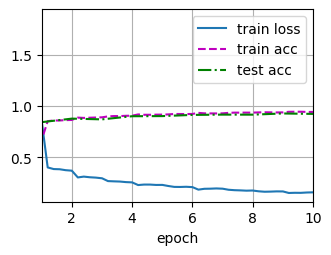

In [7]:
lr,num_epochs=0.001,10
train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())